# Uncertainty Quantification

### 1. Loading Model

In [1]:
import sys
import os
# Add the project root directory to the system path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import torch
import numpy as np
from sklearn.metrics import f1_score
from tqdm import tqdm
from src import config
from src.dataset import create_data_loader
from src.model import SentimentClassifier
from transformers import DistilBertTokenizer

# --- Load model ---
print("Loading the baseline model...")
device = torch.device(config.DEVICE)
model = SentimentClassifier(n_classes=config.N_CLASSES)
model_path = f"{config.SAVED_MODELS_PATH}/{config.SAVED_MODELS_NAME}"
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# --- Load tokenizer ---
print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained(config.MODEL_NAME)

# --- Load data ---
print("Loading data...")
val_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/" + config.VALIDATION_FILE_NAME,
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)

test_data_loader = create_data_loader(
    f"{config.PROCESSED_DATA_PATH}/" + config.TEST_FILE_NAME,
    tokenizer,
    config.MAX_LEN,
    config.BATCH_SIZE
)
print("All loading completed!")

Loading the baseline model...
Loading tokenizer...
Loading data...
All loading completed!


___
### 2.Temperature Scaling

#### 2.1 Test the confidence level of the model

In [3]:
from src.uncertainty.temperature_scaling import get_confidence_level

average_confidence, accuracy = get_confidence_level(
    val_data_loader, device, model)
# --- Print diagnostic conclusions ---
print("\n" + "="*20 + " Pre-calibration Diagnostic Report " + "="*20)
print(f"The Actual Accuracy Rate: {accuracy:.4f}")
print(f"The Average Confidence:   {average_confidence:.4f}")

print("\nConclusion:")
if average_confidence > accuracy:
    print("The model exhibits 'Overconfidence'.")
elif average_confidence < accuracy:
    print("The model exhibits 'Lack of Confidence'.")
else:
    print("The model has been calibrated well.")
print("="*64)

Calibrating the model before validation set evaluation...


Diagnosing Calibration: 100%|██████████| 156/156 [00:33<00:00,  4.61it/s]


==================== Pre-calibration Diagnostic Report ====================
The Actual Accuracy Rate: 0.8230
The Average Confidence:   0.8735

Conclusion:
The model exhibits 'Overconfidence'.


#### 2.2 Calculate the Optimal Temperature T Value

In [4]:
from src.uncertainty.temperature_scaling import find_optimal_temperature

# 1. Find the optimal T
print("\nThe temperature parameter T is optimizing...")
optimal_temperature = find_optimal_temperature(model, val_data_loader, device)

# 2. Round to four decimal places
short_temperature = round(optimal_temperature, 4)

# 3. Update parameter list
config.update_uq_params(temperature=short_temperature)
print(f"Optimization completed! Optimal temperature T = {short_temperature}")


The temperature parameter T is optimizing...
Getting Logits on Validation set...


Finding Optimal T: 100%|██████████| 156/156 [00:33<00:00,  4.62it/s]


UQ parameters have been successfully updated.
Optimization completed! Optimal temperature T = 1.2871


#### 2.3 Evaluate Calibration Effectiveness on the Test Set

In [5]:
from src.uncertainty.temperature_scaling import get_temp_logits

# 1. Retrieve Logits on the test set
test_logits, test_labels = get_temp_logits(test_data_loader, device, model)

# 2. Calculate the probability and confidence before calibration
softmaxes = torch.softmax(test_logits, dim=1)
confidences, predictions = torch.max(softmaxes, 1)

# 3. Calibrate using the optimal temperature
scaled_logits = test_logits / optimal_temperature
calibrated_softmaxes = torch.softmax(scaled_logits, dim=1)
calibrated_confidences, _ = torch.max(calibrated_softmaxes, 1)

# 4. Comparison of Average Confidence
print("\n--- Comparison of calibration effects ---")
print(f"Before calibration (T=1.0): {confidences.mean().item():.4f}")
print(
    f"After  calibration (T={optimal_temperature:.4f}): {calibrated_confidences.mean().item():.4f}")

# 5. Calculate accuracy and F1 score
accuracy = (predictions == test_labels).float().mean()
y_true = test_labels.cpu().numpy()
y_pred = predictions.cpu().numpy()
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n--- Final performance evaluation ---")
print(f"Accuracy of the model on the test set: {accuracy.item():.4f}")
print(f"Weighted F1 score of the model on the test set: {weighted_f1:.4f}")

Testing: 100%|██████████| 156/156 [00:33<00:00,  4.66it/s]


--- Comparison of calibration effects ---
Before calibration (T=1.0): 0.8768
After  calibration (T=1.2871): 0.8410

--- Final performance evaluation ---
Accuracy of the model on the test set: 0.8165
Weighted F1 score of the model on the test set: 0.8165


#### 2.4 Visualization

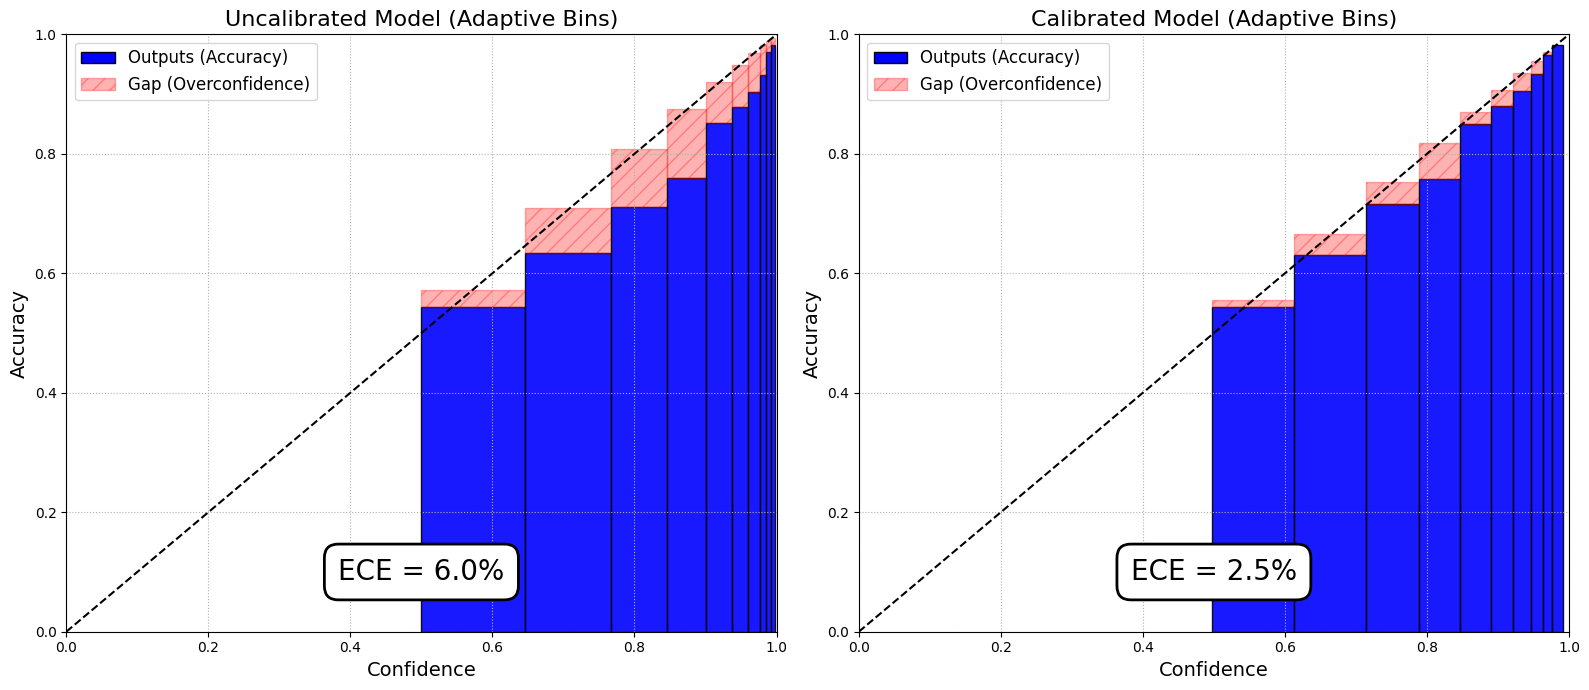

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty.temperature_scaling import plot_reliability_diagram_final

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Draw the graph before calibration
plot_reliability_diagram_final(
    axes[0],
    softmaxes.cpu().numpy(),
    y_true,
    "Uncalibrated Model (Adaptive Bins)"
)

# Draw the calibrated graph
plot_reliability_diagram_final(
    axes[1],
    calibrated_softmaxes.cpu().numpy(),
    y_true,
    "Calibrated Model (Adaptive Bins)"
)

plt.tight_layout()
plt.show()

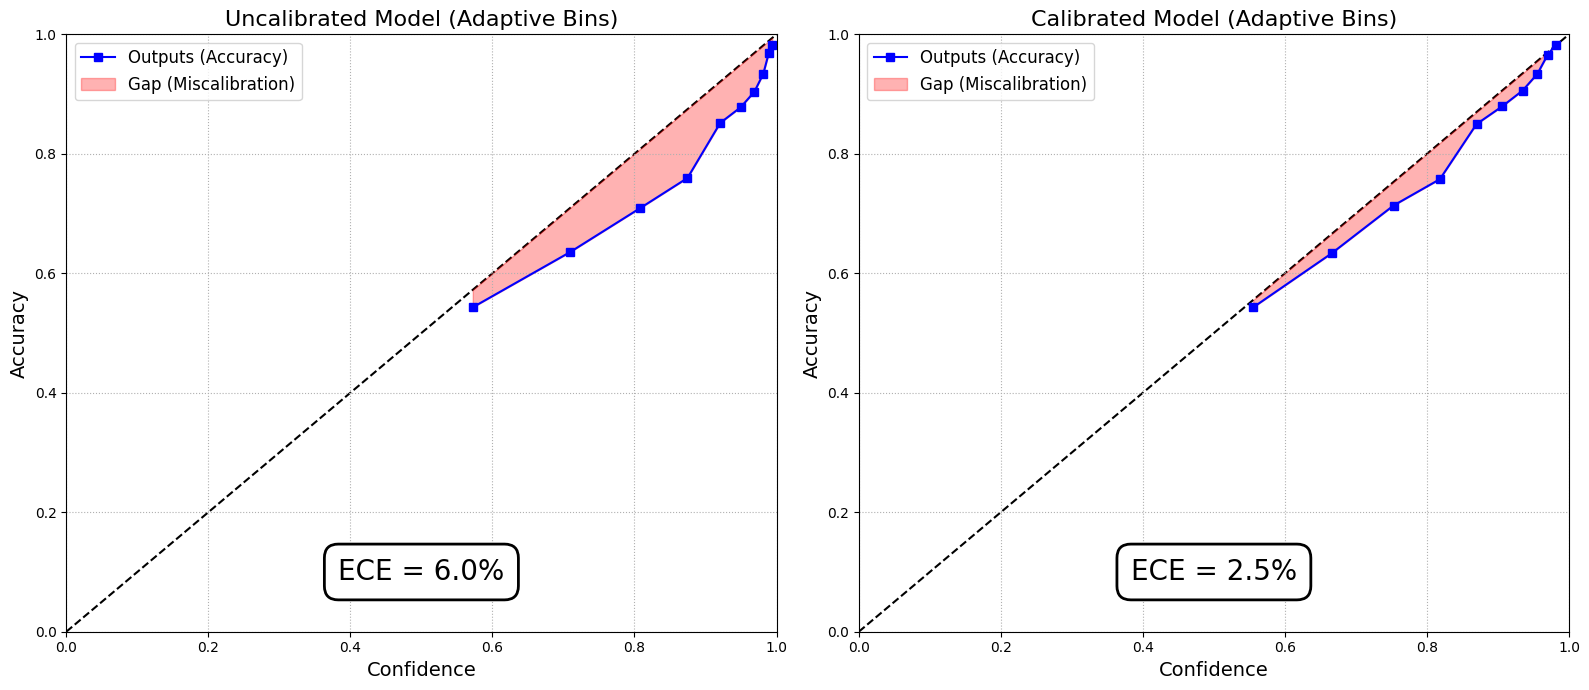

In [7]:
import matplotlib.pyplot as plt
from src.uncertainty.temperature_scaling import plot_reliability_diagram_adaptive

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Draw the graph before calibration
plot_reliability_diagram_adaptive(
    axes[0],
    softmaxes.cpu().numpy(),
    y_true,
    "Uncalibrated Model (Adaptive Bins)"
)

# Draw the calibrated graph
plot_reliability_diagram_adaptive(
    axes[1],
    calibrated_softmaxes.cpu().numpy(),
    y_true,
    "Calibrated Model (Adaptive Bins)"
)

plt.tight_layout()
plt.show()

___
### 3.MC Dropout

#### 3.1 Activate dropout

In [8]:
from src.uncertainty.mc_dropout import get_mc_dropout_predictions
from sklearn.metrics import f1_score
import numpy as np

# 1. Run MC Dropout
N_SAMPLES = config.get_uq_param('mc_sampling_times') # Set the sampling frequency
mc_results = get_mc_dropout_predictions(model, test_data_loader, N_SAMPLES, device)

# 2. Calculate traditional performance indicators
mc_accuracy = np.mean(mc_results['predictions'] == mc_results['labels'])
mc_f1 = f1_score(mc_results['labels'], mc_results['predictions'], average='weighted', zero_division=0)

print("\n--- MC Dropout Performance Evaluation ---")
print(f"Accuracy on the test set: {mc_accuracy:.4f}")
print(f"Weighted F1 score on the test set: {mc_f1:.4f}")

MC Dropout (N=10): 100%|██████████| 156/156 [03:36<00:00,  1.39s/it]


--- MC Dropout Performance Evaluation ---
Accuracy on the test set: 0.8177
Weighted F1 score on the test set: 0.8176


#### 3.2 Visualization

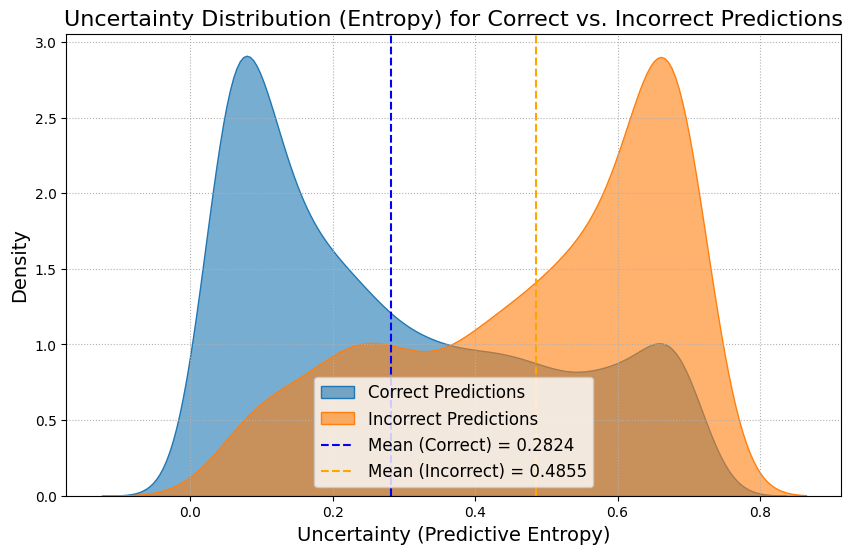

In [9]:
import seaborn as sns


def calculate_predictive_entropy(probs):
    """
    Calculate predicted entropy
    """
    # Calculate entropy for the average probability of each sample
    mean_probs = np.mean(probs, axis=0)
    # Add a very small number epsilon to prevent log (0)
    epsilon = 1e-10
    # If the probability distribution is smooth (the model is hesitant), the entropy value is high
    # If the probability distribution is sharp (the model is confident), the entropy value is low
    entropy = -np.sum(mean_probs * np.log(mean_probs + epsilon), axis=1)
    return entropy


# Calculate predicted entropy
uncertainty_scores = calculate_predictive_entropy(mc_results['raw_probs'])
is_correct = mc_results['predictions'] == mc_results['labels']

# Draw KDE diagram
plt.figure(figsize=(10, 6))

sns.kdeplot(uncertainty_scores[is_correct],
            label='Correct Predictions', fill=True, alpha=0.6)
sns.kdeplot(uncertainty_scores[~is_correct],
            label='Incorrect Predictions', fill=True, alpha=0.6)

mean_entropy_correct = np.mean(uncertainty_scores[is_correct])
mean_entropy_incorrect = np.mean(uncertainty_scores[~is_correct])
plt.axvline(mean_entropy_correct, color='blue', linestyle='--',
            label=f'Mean (Correct) = {mean_entropy_correct:.4f}')
plt.axvline(mean_entropy_incorrect, color='orange', linestyle='--',
            label=f'Mean (Incorrect) = {mean_entropy_incorrect:.4f}')

plt.xlabel("Uncertainty (Predictive Entropy)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Uncertainty Distribution (Entropy) for Correct vs. Incorrect Predictions", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='dotted')
plt.show()

___
### 4. Conformal Prediction

#### 4.1 Calculate Softmax

In [10]:
from src.uncertainty.conformal_prediction import get_softmax_outputs

model.eval()

# Get Softmax output for validation and test sets
y_calib_probs, y_calib_true = get_softmax_outputs(val_data_loader, model, device)
y_test_probs, y_test_true = get_softmax_outputs(test_data_loader, model, device)

print("Successfully obtained Softmax outputs for validation and test sets.")

Getting softmax outputs: 100%|██████████| 156/156 [00:33<00:00,  4.70it/s]

Successfully obtained Softmax outputs for validation and test sets.


#### 4.2 Calculate Prediction Set

In [11]:
import torch
from tqdm import tqdm
from src import config
from src.uncertainty.conformal_prediction import conformal_predict, evaluate_conformal, find_conformal_threshold

# --- 1. Prepare Data ---
print("="*70)
print("The data is ready.")
print(f"Validation Set size: {len(y_calib_true)}")
print(f"Test Set size: {len(y_test_true)}")

# --- 2. Run conformal prediction ---
print("="*70)
alpha = config.get_uq_param('conformal_alpha')  # Corresponding to a 95% confidence level
print(f"Start performing conformal prediction (confidence level = {1-alpha:.0%})...")
prediction_sets = conformal_predict(y_calib_probs, y_calib_true, y_test_probs, alpha)

# --- 3. Calculate q-hat ---
print("="*70)
print(f"Start calculating the calibration threshold (confidence level= {1-alpha:.0%})...")
q_hat = find_conformal_threshold(model, val_data_loader, device, alpha)
print(f"Calibration threshold q-hat for conformal prediction= {q_hat:.4f}")
# Round to four decimal places
short_q_hat = round(float(q_hat), 4)
# Update parameter list
config.update_uq_params(conformal_q_hat=short_q_hat)

# --- 4. Evaluation results ---
coverage, avg_set_size = evaluate_conformal(y_test_true, prediction_sets)

print("\n" + "="*10 + " Conformal prediction evaluation results on the test set " + "="*10)
print(f"Pre-set confidence level: {1-alpha:.2f}")
print(f"Actual coverage: {coverage:.4f}")
print(f"Average prediction set size: {avg_set_size:.4f}")
print("="*70)

# 5. View some examples of predicted results
print("\nExample of Prediction Results (Top 5):")
for i in range(5):
    class_names_in_set = {config.CLASS_NAMES[label] for label in prediction_sets[i]}
    print(f"  - Sample {i}: Real Label='{config.CLASS_NAMES[y_test_true[i]]}', "
          f"Prediction Set={class_names_in_set}")

The data is ready.
Validation Set size: 4990
Test Set size: 4991
Start performing conformal prediction (confidence level = 95%)...


Generating Prediction Sets: 100%|██████████| 4991/4991 [00:00<00:00, 557475.73it/s]


Start calculating the calibration threshold (confidence level= 95%)...


Calibrating Conformal Threshold: 100%|██████████| 156/156 [00:33<00:00,  4.67it/s]

Calibration threshold q-hat for conformal prediction= 0.9054
UQ parameters have been successfully updated.

========== Conformal prediction evaluation results on the test set ==========
Pre-set confidence level: 0.95
Actual coverage: 0.9527
Average prediction set size: 1.4091

Example of Prediction Results (Top 5):
  - Sample 0: Real Label='negative', Prediction Set={'positive', 'negative'}
  - Sample 1: Real Label='negative', Prediction Set={'positive', 'negative'}
  - Sample 2: Real Label='negative', Prediction Set={'negative'}
  - Sample 3: Real Label='positive', Prediction Set={'positive'}
  - Sample 4: Real Label='negative', Prediction Set={'negative'}


#### 4.3 Visualization

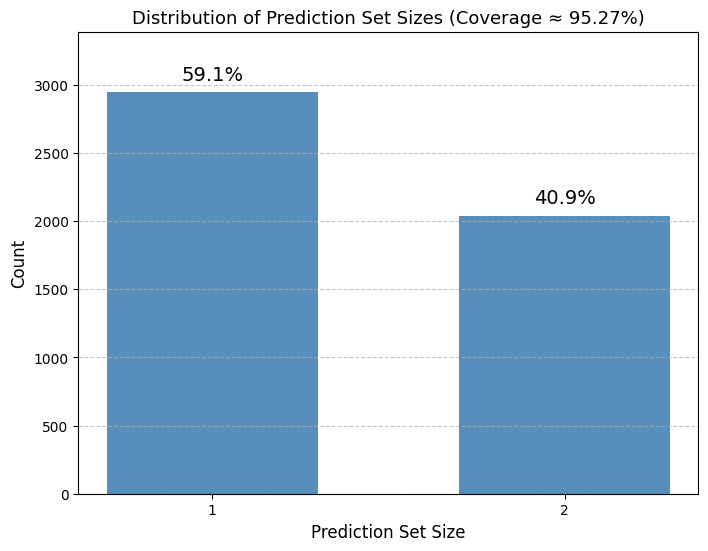

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate the size of each prediction set
set_sizes = [len(s) for s in prediction_sets]

# 2. Count the number of prediction sets of different sizes
size_counts = pd.Series(set_sizes).value_counts().sort_index()

# 3. Start drawing
plt.figure(figsize=(8, 6)) 

bars = plt.bar(
    size_counts.index, 
    size_counts.values, 
    color='steelblue',
    width=0.6,
    alpha=0.9
)

plt.xlabel("Prediction Set Size", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title(f"Distribution of Prediction Set Sizes (Coverage ≈ {coverage:.2%})", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)

total_samples = len(set_sizes)
y_max = size_counts.max()
plt.ylim(0, y_max * 1.15) 

# Display percentage above each column
for bar in bars:
    height = bar.get_height()
    percentage = f"{(height / total_samples) * 100:.1f}%"
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + (y_max * 0.02),
        percentage, 
        ha='center', 
        va='bottom', 
        fontsize=14
    )

plt.xticks(size_counts.index)
plt.show()

Calculating coverage under different alpha values...


100%|██████████| 25/25 [00:00<00:00, 64.01it/s]
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


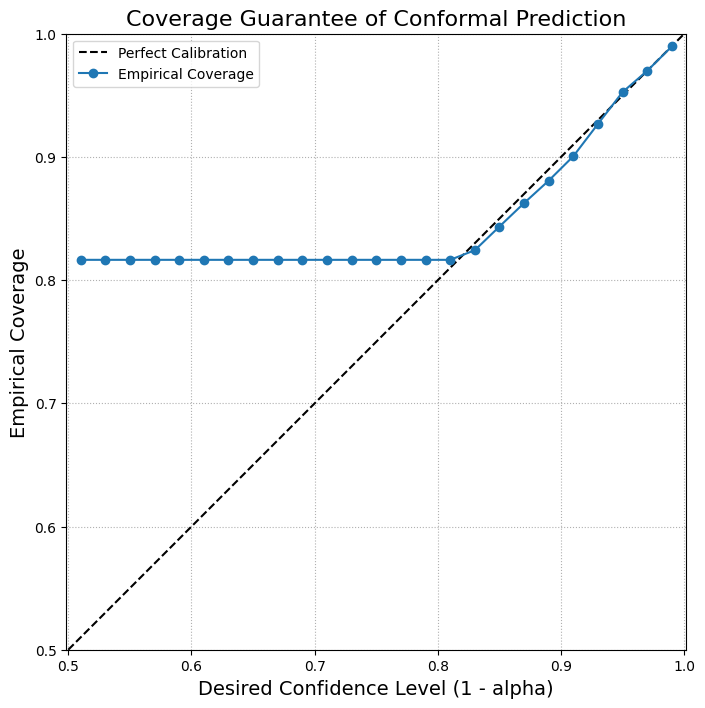

In [14]:
# Test on a series of alpha values
alphas = np.arange(0.01, 0.5, 0.02)
actual_coverages = []

print("Calculating coverage under different alpha values...")
for alpha_level in tqdm(alphas):
    # Regenerate the prediction set
    temp_prediction_sets = conformal_predict(
        y_calib_probs, y_calib_true, y_test_probs, alpha=alpha_level)
    # Calculate and record coverage rate
    coverage, _ = evaluate_conformal(y_test_true, temp_prediction_sets)
    actual_coverages.append(coverage)

# Expected confidence level
desired_confidences = 1 - alphas

plt.figure(figsize=(8, 8))
plt.plot([0.5, 1], [0.5, 1], 'k--', label="Perfect Calibration")

plt.plot(desired_confidences, actual_coverages,
         'o-', label="Empirical Coverage")
plt.xlabel("Desired Confidence Level (1 - alpha)", fontsize=14)
plt.ylabel("Empirical Coverage", fontsize=14)
plt.title("Coverage Guarantee of Conformal Prediction", fontsize=16)
plt.axis('equal')
plt.xlim([0.5, 1])
plt.ylim([0.5, 1])
plt.legend()
plt.grid(True, linestyle='dotted')
plt.show()

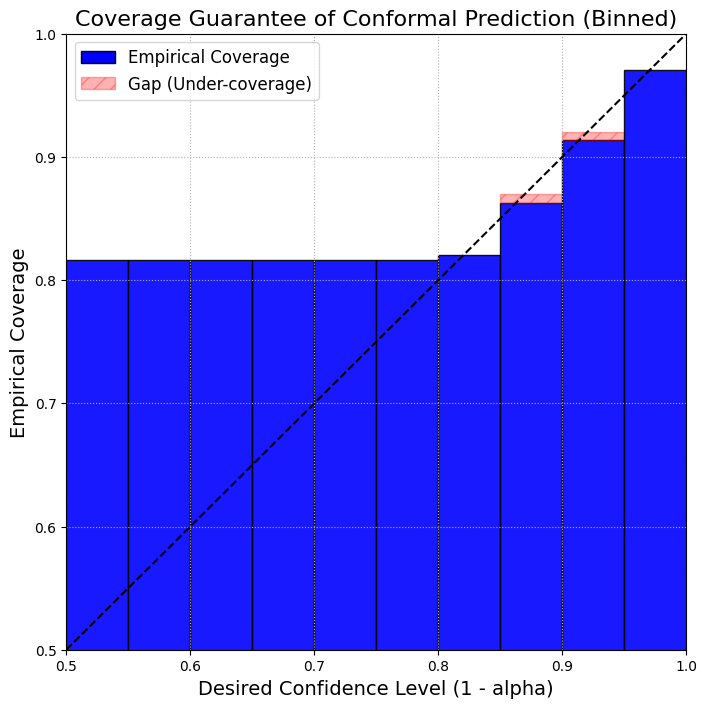

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty.conformal_prediction import plot_coverage_guarantee_binned

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

plot_coverage_guarantee_binned(
    ax,
    np.array(desired_confidences),
    np.array(actual_coverages),
    "Coverage Guarantee of Conformal Prediction (Binned)"
)

plt.show()

___
### 5.SNGP

#### 5.1 Load SNGP Model

In [16]:
from src.uncertainty.sngp_model import SNGPClassifier

print("Loading the trained SNGP model...")
sngp_model = SNGPClassifier(n_classes=config.N_CLASSES)
sngp_model_path = os.path.join(config.SAVED_MODELS_PATH, config.SAVED_SNGP_MODELS_NAME)
sngp_model.load_state_dict(torch.load(sngp_model_path, map_location=device))
sngp_model = sngp_model.to(device)
sngp_model.eval()
print("The SNGP model has been successfully loaded!")

Loading the trained SNGP model...
The SNGP model has been successfully loaded!


#### 5.2 Run and test the effectiveness of the SNGP model

In [17]:
import torch.nn.functional as F

# --- 1. Obtain the prediction probability of the SNGP model on the test set ---
sngp_all_probs = []
with torch.no_grad():
    for d in tqdm(test_data_loader, desc="Evaluating SNGP Model"):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)

        outputs = sngp_model(input_ids=input_ids,
                             attention_mask=attention_mask)
        probs = F.softmax(outputs, dim=1)
        sngp_all_probs.append(probs)

sngp_all_probs = torch.cat(sngp_all_probs).cpu().numpy()


# --- 2. Calculate the performance metrics of the SNGP model ---
sngp_predictions = np.argmax(sngp_all_probs, axis=1)
sngp_accuracy = np.mean(sngp_predictions == y_true)
sngp_f1 = f1_score(y_true, sngp_predictions,
                   average='weighted', zero_division=0)

print("\n--- The final performance of the SNGP model on the test set ---")
print(f"Accuracy: {sngp_accuracy:.4f}")
print(f"Weighted F1 Score: {sngp_f1:.4f}")

Evaluating SNGP Model: 100%|██████████| 156/156 [00:34<00:00,  4.58it/s]


--- The final performance of the SNGP model on the test set ---
Accuracy: 0.8149
Weighted F1 Score: 0.8149


#### 5.3 Visualization

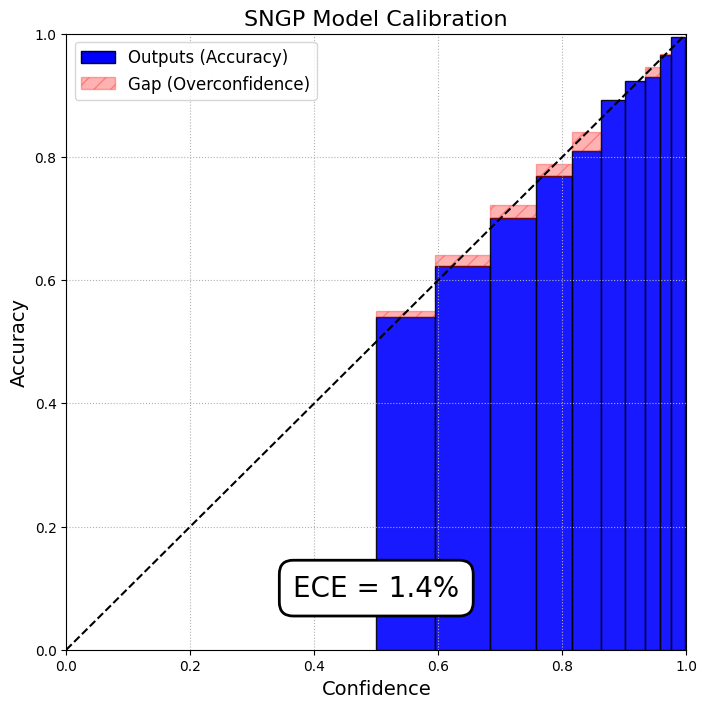

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

plot_reliability_diagram_final(
    ax, sngp_all_probs, y_true, "SNGP Model Calibration")
plt.show()